In [29]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Upload Featured Engineered Dataset

from google.colab import files
uploaded = files.upload()
df = pd.read_csv("processed-data.csv")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Saving processed-data.csv to processed-data.csv
Dataset shape: (1470, 31)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Stayed : 1233  (83.9%)
Left   : 237 (16.1%)


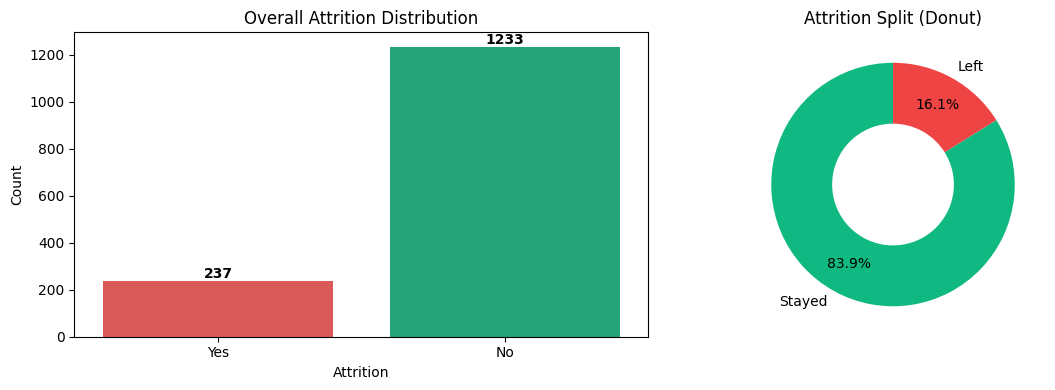

In [5]:
# ATTRITION OVERVIEW

attrition_counts = df["Attrition"].value_counts()
print(f"Stayed : {attrition_counts['No']}  ({attrition_counts['No']/len(df)*100:.1f}%)")
print(f"Left   : {attrition_counts['Yes']} ({attrition_counts['Yes']/len(df)*100:.1f}%)")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x="Attrition", data=df, ax=axes[0],
              palette={"No": "#10b981", "Yes": "#ef4444"})
axes[0].set_title("Overall Attrition Distribution")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Donut chart
colors = ["#10b981", "#ef4444"]
axes[1].pie([attrition_counts["No"], attrition_counts["Yes"]],
            labels=["Stayed", "Left"],
            autopct="%1.1f%%", colors=colors,
            startangle=90, pctdistance=0.75,
            wedgeprops=dict(width=0.5))
axes[1].set_title("Attrition Split (Donut)")

plt.tight_layout()
plt.savefig("trend_attrition_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# OVERTIME & TRAVEL TRENDS

# Overtime attrition rate
ot_rate = df.groupby("OverTime")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(1)
print("Attrition Rate by Overtime:")
print(ot_rate)

Attrition Rate by Overtime:
OverTime
No     10.4
Yes    30.5
Name: Attrition, dtype: float64



Attrition Rate by Business Travel:
BusinessTravel
Non-Travel            8.0
Travel_Frequently    24.9
Travel_Rarely        15.0
Name: Attrition, dtype: float64


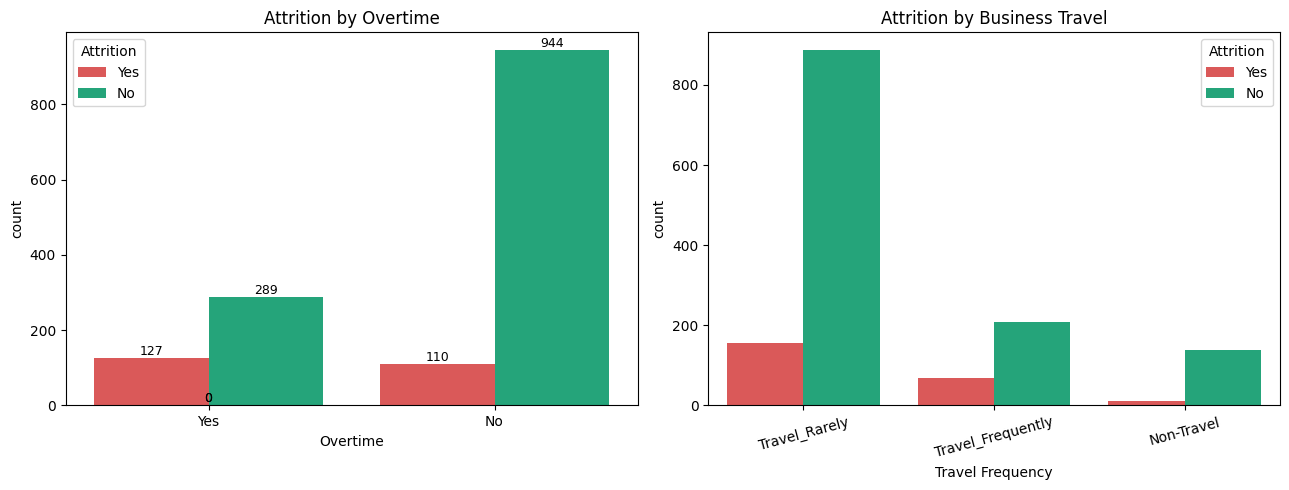

In [8]:
# Travel attrition rate

travel_rate = df.groupby("BusinessTravel")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(1)
print("\nAttrition Rate by Business Travel:")
print(travel_rate)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overtime
sns.countplot(x="OverTime", hue="Attrition", data=df, ax=axes[0],
              palette={"No": "#10b981", "Yes": "#ef4444"})
axes[0].set_title("Attrition by Overtime")
axes[0].set_xlabel("Overtime")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Business Travel
sns.countplot(x="BusinessTravel", hue="Attrition", data=df, ax=axes[1],
              palette={"No": "#10b981", "Yes": "#ef4444"})
axes[1].set_title("Attrition by Business Travel")
axes[1].set_xlabel("Travel Frequency")
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("trend_overtime_travel.png", dpi=150, bbox_inches="tight")
plt.show()

Attrition Rate by Department:
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition, dtype: float64

Attrition Rate by Job Role:
JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Healthcare Representative     6.9
Manufacturing Director        6.9
Manager                       4.9
Research Director             2.5
Name: Attrition, dtype: float64


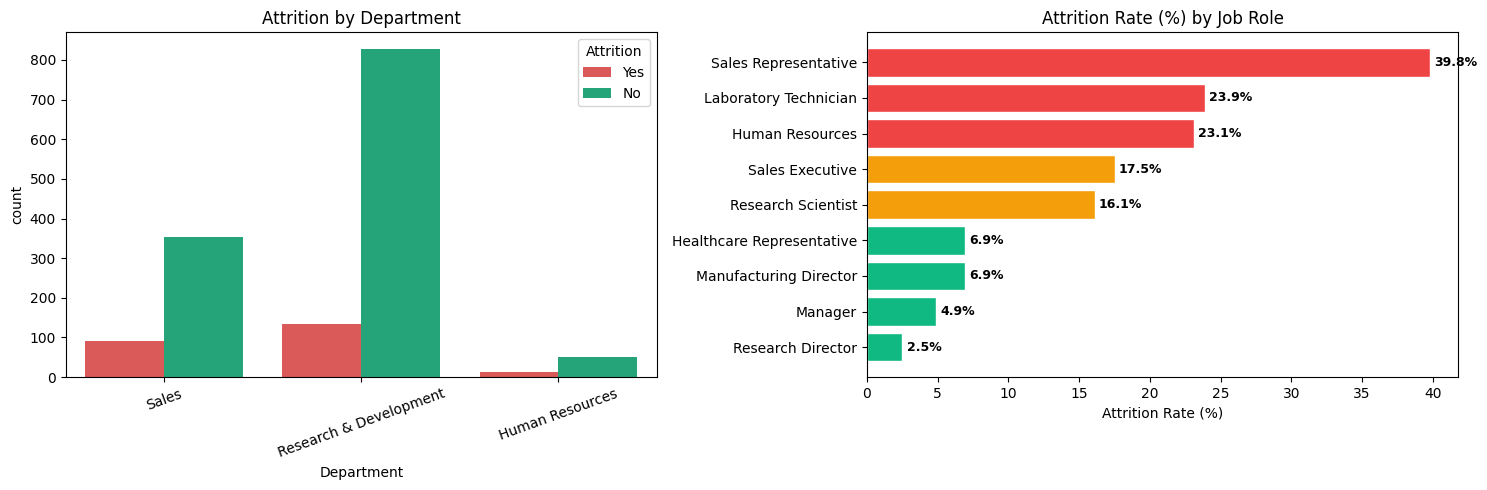

In [10]:
# DEPARTMENT & JOB ROLE TRENDS

dept_rate = df.groupby("Department")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(1).sort_values(ascending=False)
print("Attrition Rate by Department:")
print(dept_rate)
role_rate = df.groupby("JobRole")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(1).sort_values(ascending=False)
print("\nAttrition Rate by Job Role:")
print(role_rate)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Department count
sns.countplot(x="Department", hue="Attrition", data=df, ax=axes[0],
              palette={"No": "#10b981", "Yes": "#ef4444"})
axes[0].set_title("Attrition by Department")
axes[0].tick_params(axis='x', rotation=20)

# Job Role attrition rate
colors_role = ["#ef4444" if v > 20 else "#f59e0b" if v > 10 else "#10b981"
               for v in role_rate.values]
bars = axes[1].barh(role_rate.index[::-1], role_rate.values[::-1],
                    color=colors_role[::-1], edgecolor="white")
axes[1].set_title("Attrition Rate (%) by Job Role")
axes[1].set_xlabel("Attrition Rate (%)")
for bar, val in zip(bars, role_rate.values[::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig("trend_dept_role.png", dpi=150, bbox_inches="tight")
plt.show()

Mean Income — Stayed: $6,833
Mean Income — Left:   $4,787
Median Income — Stayed: $5,204
Median Income — Left:   $3,202


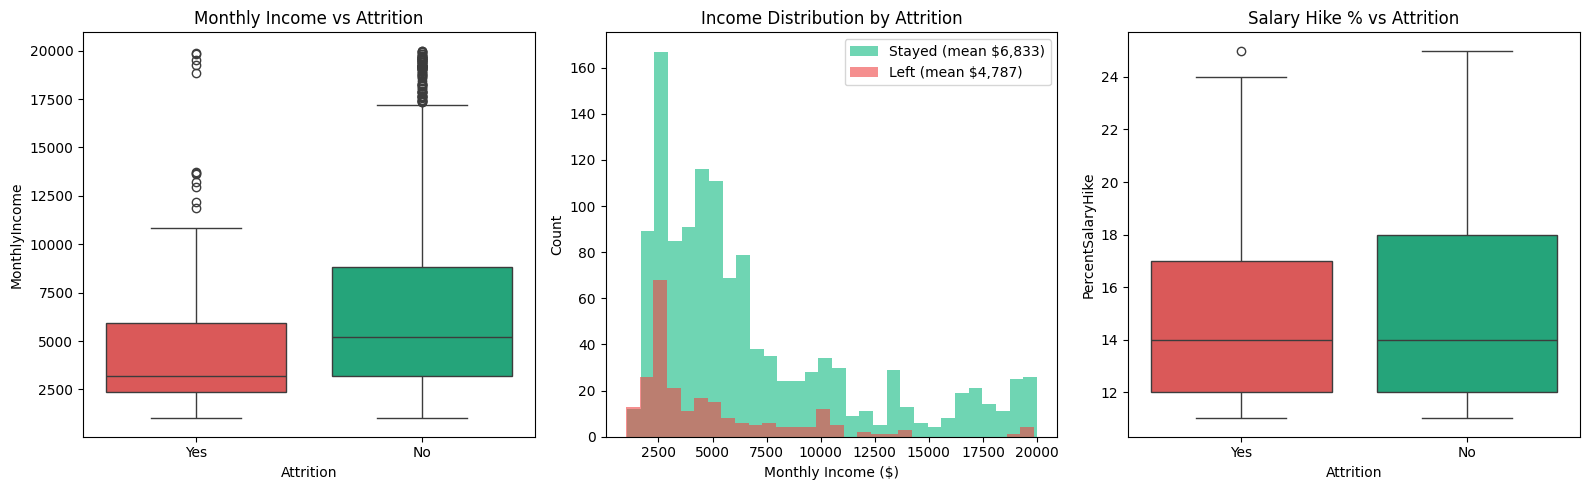

In [12]:
# COMPENSATION TRENDS

stayed_income = df[df["Attrition"] == "No"]["MonthlyIncome"]
left_income   = df[df["Attrition"] == "Yes"]["MonthlyIncome"]
print(f"Mean Income — Stayed: ${stayed_income.mean():,.0f}")
print(f"Mean Income — Left:   ${left_income.mean():,.0f}")
print(f"Median Income — Stayed: ${stayed_income.median():,.0f}")
print(f"Median Income — Left:   ${left_income.median():,.0f}")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Box plot
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, ax=axes[0],
            palette={"No": "#10b981", "Yes": "#ef4444"})
axes[0].set_title("Monthly Income vs Attrition")

# Histogram overlay
axes[1].hist(stayed_income, bins=30, alpha=0.6, color="#10b981",
             label=f"Stayed (mean ${stayed_income.mean():,.0f})")
axes[1].hist(left_income, bins=30, alpha=0.6, color="#ef4444",
             label=f"Left (mean ${left_income.mean():,.0f})")
axes[1].set_title("Income Distribution by Attrition")
axes[1].set_xlabel("Monthly Income ($)")
axes[1].set_ylabel("Count")
axes[1].legend()

# Salary Hike
sns.boxplot(x="Attrition", y="PercentSalaryHike", data=df, ax=axes[2],
            palette={"No": "#10b981", "Yes": "#ef4444"})
axes[2].set_title("Salary Hike % vs Attrition")

plt.tight_layout()
plt.savefig("trend_compensation.png", dpi=150, bbox_inches="tight")
plt.show()


SECTION 5: SATISFACTION TRENDS
JobSatisfaction: Stayed=2.78  Left=2.47
EnvironmentSatisfaction: Stayed=2.77  Left=2.46
WorkLifeBalance: Stayed=2.78  Left=2.66
RelationshipSatisfaction: Stayed=2.73  Left=2.6


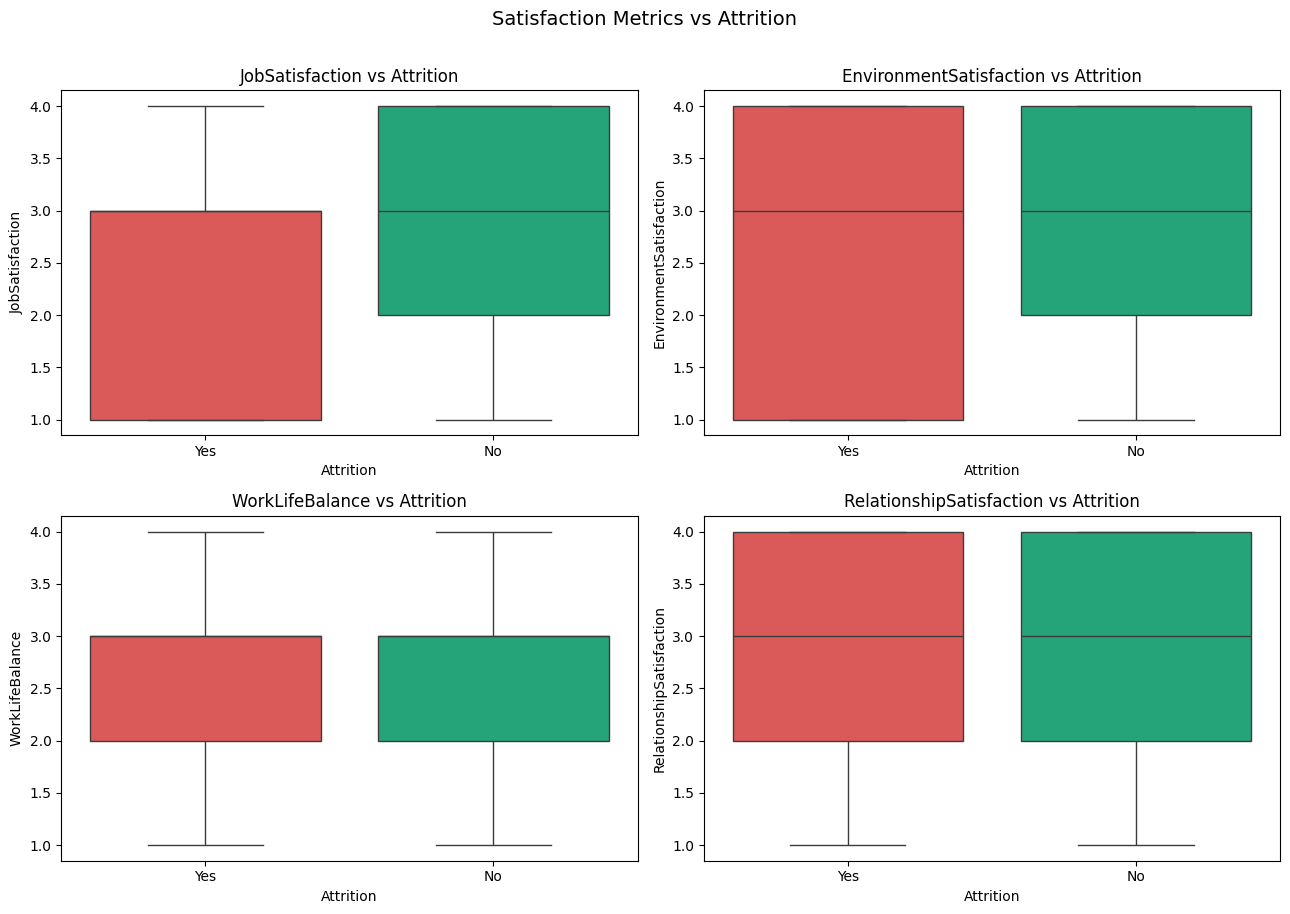

In [13]:
# SATISFACTION TRENDS

print("\n" + "="*60)
print("SECTION 5: SATISFACTION TRENDS")
print("="*60)

sat_cols = ["JobSatisfaction", "EnvironmentSatisfaction",
            "WorkLifeBalance", "RelationshipSatisfaction"]

for col in sat_cols:
    stayed_mean = df[df["Attrition"] == "No"][col].mean().round(2)
    left_mean   = df[df["Attrition"] == "Yes"][col].mean().round(2)
    print(f"{col}: Stayed={stayed_mean}  Left={left_mean}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(sat_cols):
    sns.boxplot(x="Attrition", y=col, data=df, ax=axes[i],
                palette={"No": "#10b981", "Yes": "#ef4444"})
    axes[i].set_title(f"{col} vs Attrition")

plt.suptitle("Satisfaction Metrics vs Attrition", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("trend_satisfaction.png", dpi=150, bbox_inches="tight")
plt.show()


YearsAtCompany: Stayed=7.37  Left=5.13
TotalWorkingYears: Stayed=11.86  Left=8.24
YearsSinceLastPromotion: Stayed=2.23  Left=1.95
YearsWithCurrManager: Stayed=4.37  Left=2.85


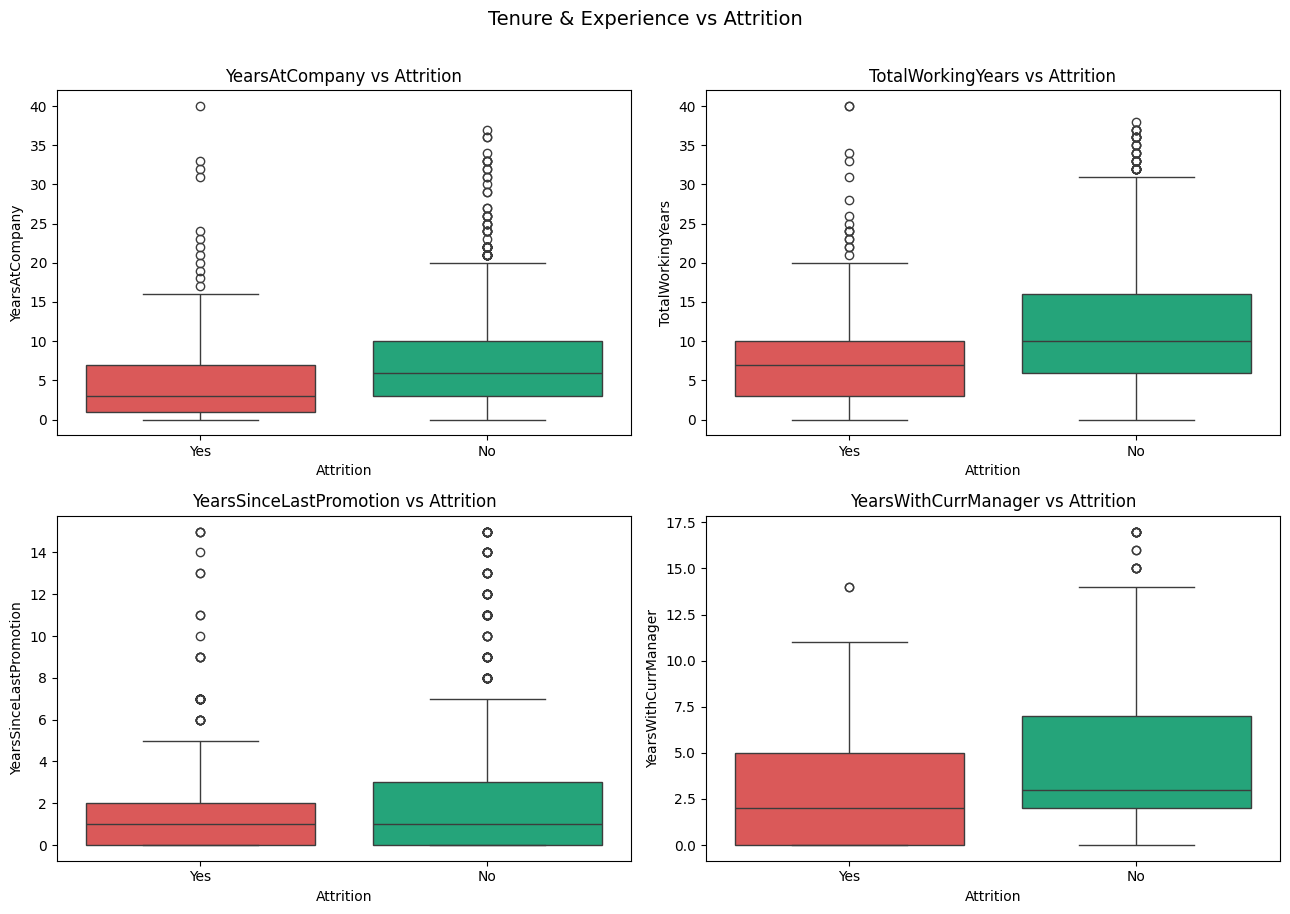

In [15]:
# TENURE & EXPERIENCE TRENDS

tenure_cols = ["YearsAtCompany", "TotalWorkingYears",
               "YearsSinceLastPromotion", "YearsWithCurrManager"]

for col in tenure_cols:
    stayed_mean = df[df["Attrition"] == "No"][col].mean().round(2)
    left_mean   = df[df["Attrition"] == "Yes"][col].mean().round(2)
    print(f"{col}: Stayed={stayed_mean}  Left={left_mean}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(tenure_cols):
    sns.boxplot(x="Attrition", y=col, data=df, ax=axes[i],
                palette={"No": "#10b981", "Yes": "#ef4444"})
    axes[i].set_title(f"{col} vs Attrition")

plt.suptitle("Tenure & Experience vs Attrition", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("trend_tenure.png", dpi=150, bbox_inches="tight")
plt.show()


Attrition Rate by Gender:
Gender
Female    14.8
Male      17.0
Name: Attrition, dtype: float64

Attrition Rate by Marital Status:
MaritalStatus
Divorced    10.1
Married     12.5
Single      25.5
Name: Attrition, dtype: float64

Attrition Rate by Education Field:
EducationField
Human Resources     25.9
Technical Degree    24.2
Marketing           22.0
Life Sciences       14.7
Medical             13.6
Other               13.4
Name: Attrition, dtype: float64


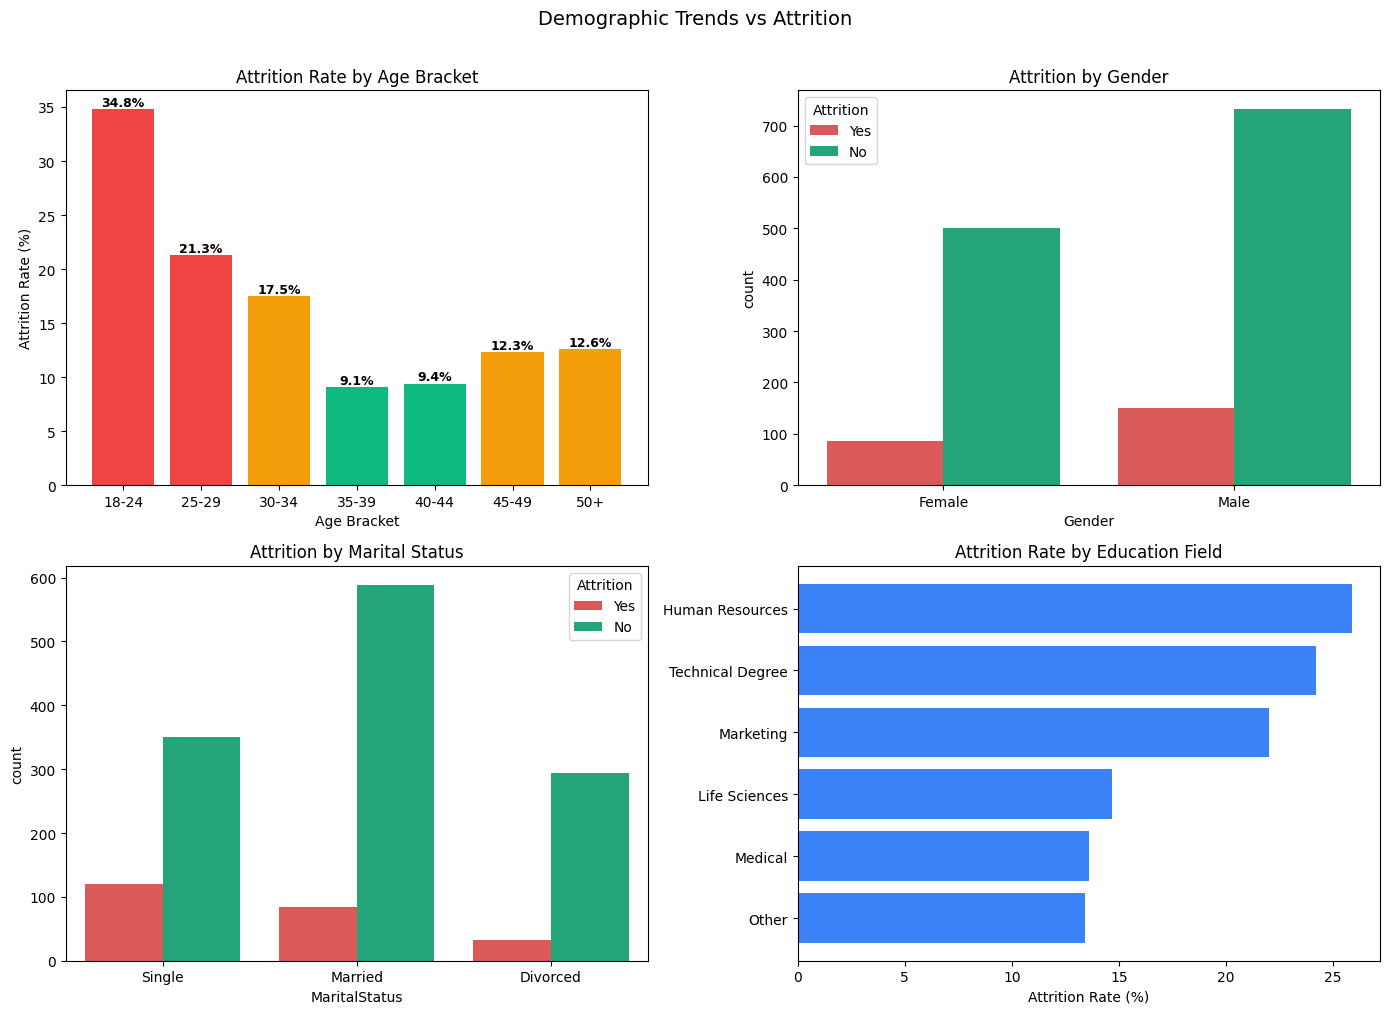

In [31]:
# DEMOGRAPHIC TRENDS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
# Age distribution
df["AgeBracket"] = pd.cut(df["Age"],
    bins=[18, 25, 30, 35, 40, 45, 50, 65],
    labels=["18-24","25-29","30-34","35-39","40-44","45-49","50+"])
age_attr = df.groupby("AgeBracket", observed=True)["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100).round(1)
axes[0].bar(age_attr.index.astype(str), age_attr.values,
            color=["#ef4444" if v > 20 else "#f59e0b" if v > 10 else "#10b981"
                   for v in age_attr.values])
axes[0].set_title("Attrition Rate by Age Bracket")
axes[0].set_xlabel("Age Bracket")
axes[0].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(age_attr.values):
    axes[0].text(i, v + 0.3, f"{v}%", ha='center', fontsize=9, fontweight='bold')

# Gender
gender_rate = df.groupby("Gender")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100).round(1)
print("\nAttrition Rate by Gender:")
print(gender_rate)
sns.countplot(x="Gender", hue="Attrition", data=df, ax=axes[1],
              palette={"No": "#10b981", "Yes": "#ef4444"})
axes[1].set_title("Attrition by Gender")

# Marital Status
marital_rate = df.groupby("MaritalStatus")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100).round(1)
print("\nAttrition Rate by Marital Status:")
print(marital_rate)
sns.countplot(x="MaritalStatus", hue="Attrition", data=df, ax=axes[2],
              palette={"No": "#10b981", "Yes": "#ef4444"})
axes[2].set_title("Attrition by Marital Status")

# Education Field
edu_rate = df.groupby("EducationField")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100).round(1).sort_values(ascending=False)
print("\nAttrition Rate by Education Field:")
print(edu_rate)
axes[3].barh(edu_rate.index[::-1], edu_rate.values[::-1], color="#3b82f6")
axes[3].set_title("Attrition Rate by Education Field")
axes[3].set_xlabel("Attrition Rate (%)")

plt.suptitle("Demographic Trends vs Attrition", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("trend_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

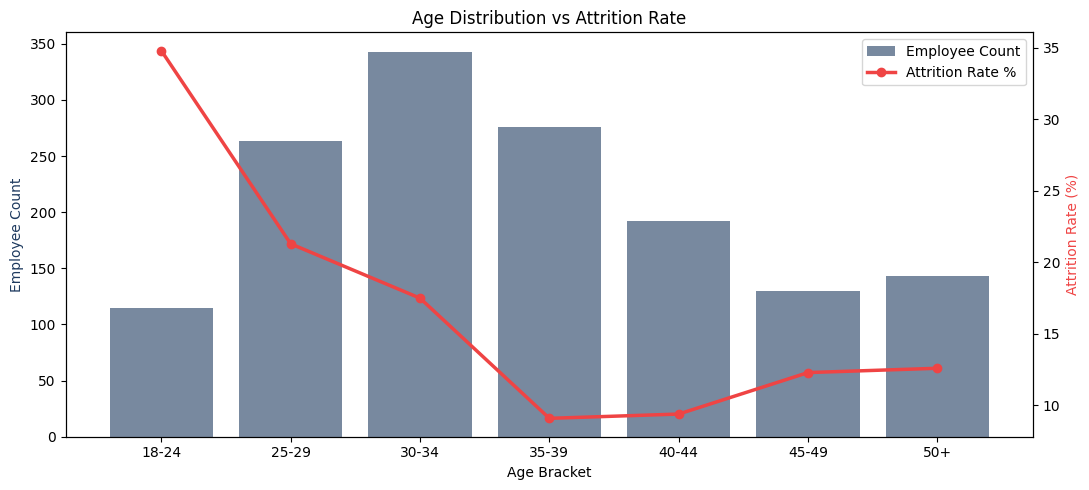

In [33]:
# AGE DISTRIBUTION FULL

fig, ax1 = plt.subplots(figsize=(11, 5))
age_count = df.groupby("AgeBracket", observed=True).size()
ax2 = ax1.twinx()
bars = ax1.bar(age_attr.index.astype(str), age_count.values,
               color="#1e3a5f", alpha=0.6, label="Employee Count")
line = ax2.plot(age_attr.index.astype(str), age_attr.values,
                color="#ef4444", marker="o", linewidth=2.5,
                label="Attrition Rate %")
ax1.set_xlabel("Age Bracket")
ax1.set_ylabel("Employee Count", color="#1e3a5f")
ax2.set_ylabel("Attrition Rate (%)", color="#ef4444")
ax1.set_title("Age Distribution vs Attrition Rate")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.savefig("trend_age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Attrition Rate by Stock Option Level:
StockOptionLevel
0    24.4
1     9.4
2     7.6
3    17.6
Name: Attrition, dtype: float64

Attrition Rate by Job Level:
JobLevel
1    26.3
2     9.7
3    14.7
4     4.7
5     7.2
Name: Attrition, dtype: float64


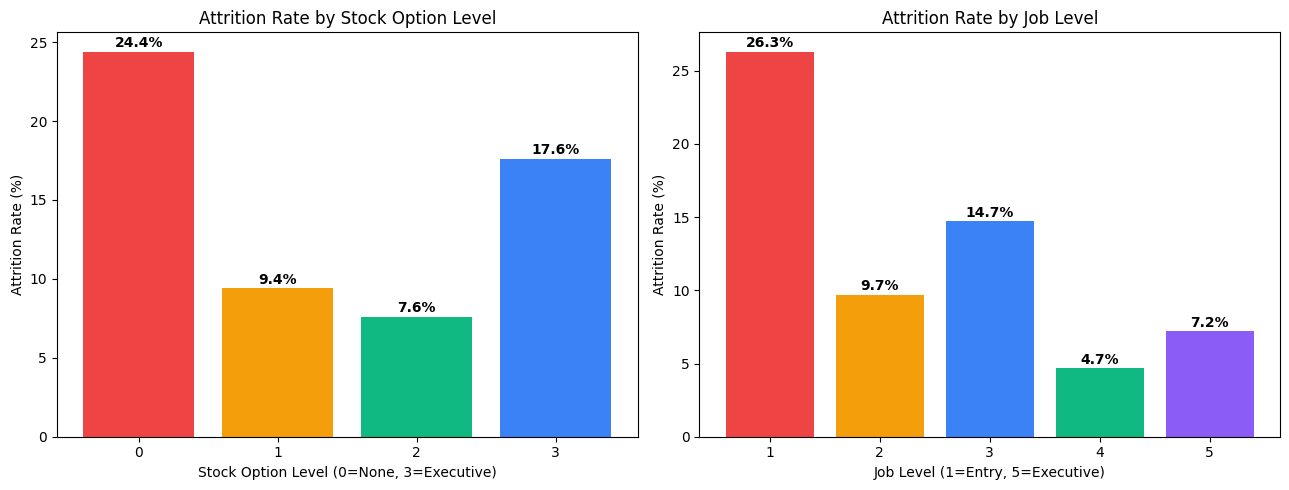

In [34]:
# STOCK OPTIONS & JOB LEVEL

stock_rate = df.groupby("StockOptionLevel")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100).round(1)
level_rate = df.groupby("JobLevel")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100).round(1)

print("Attrition Rate by Stock Option Level:")
print(stock_rate)
print("\nAttrition Rate by Job Level:")
print(level_rate)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(stock_rate.index.astype(str), stock_rate.values,
            color=["#ef4444","#f59e0b","#10b981","#3b82f6"])
axes[0].set_title("Attrition Rate by Stock Option Level")
axes[0].set_xlabel("Stock Option Level (0=None, 3=Executive)")
axes[0].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(stock_rate.values):
    axes[0].text(i, v + 0.3, f"{v}%", ha='center', fontweight='bold')

axes[1].bar(level_rate.index.astype(str), level_rate.values,
            color=["#ef4444","#f59e0b","#3b82f6","#10b981","#8b5cf6"])
axes[1].set_title("Attrition Rate by Job Level")
axes[1].set_xlabel("Job Level (1=Entry, 5=Executive)")
axes[1].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(level_rate.values):
    axes[1].text(i, v + 0.3, f"{v}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("trend_stock_joblevel.png", dpi=150, bbox_inches="tight")
plt.show()

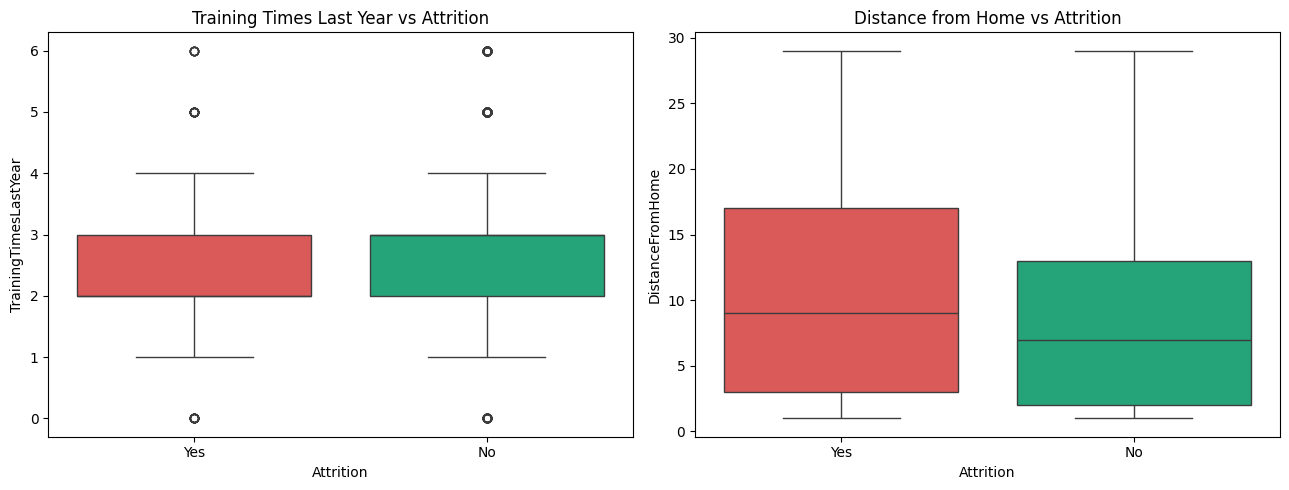

In [35]:
# TRAINING & DISTANCE TRENDS

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x="Attrition", y="TrainingTimesLastYear", data=df, ax=axes[0],
            palette={"No": "#10b981", "Yes": "#ef4444"})
axes[0].set_title("Training Times Last Year vs Attrition")

sns.boxplot(x="Attrition", y="DistanceFromHome", data=df, ax=axes[1],
            palette={"No": "#10b981", "Yes": "#ef4444"})
axes[1].set_title("Distance from Home vs Attrition")

plt.tight_layout()
plt.savefig("trend_training_distance.png", dpi=150, bbox_inches="tight")
plt.show()

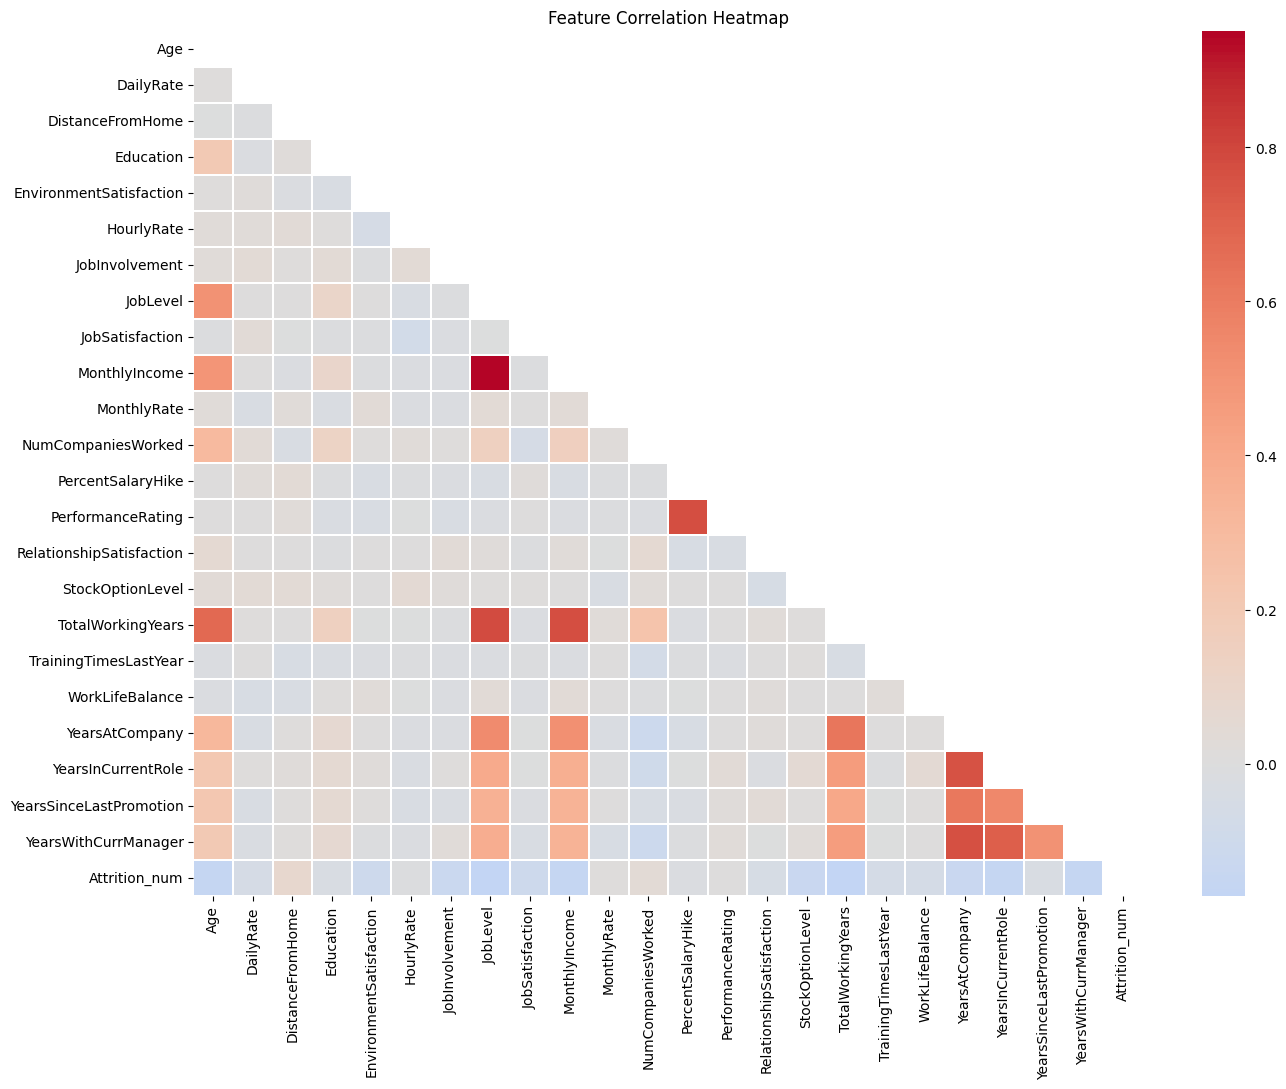

In [36]:
# CORRELATION HEATMAP

df_corr = df.copy()
df_corr["Attrition_num"] = (df_corr["Attrition"] == "Yes").astype(int)
numeric_df = df_corr.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 11))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm",
            center=0, annot=False, linewidths=0.3)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("trend_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


Top 15 Features Correlated with Attrition:
TotalWorkingYears         -0.171063
JobLevel                  -0.169105
YearsInCurrentRole        -0.160545
MonthlyIncome             -0.159840
Age                       -0.159205
YearsWithCurrManager      -0.156199
StockOptionLevel          -0.137145
YearsAtCompany            -0.134392
JobInvolvement            -0.130016
JobSatisfaction           -0.103481
EnvironmentSatisfaction   -0.103369
DistanceFromHome           0.077924
WorkLifeBalance           -0.063939
TrainingTimesLastYear     -0.059478
DailyRate                 -0.056652


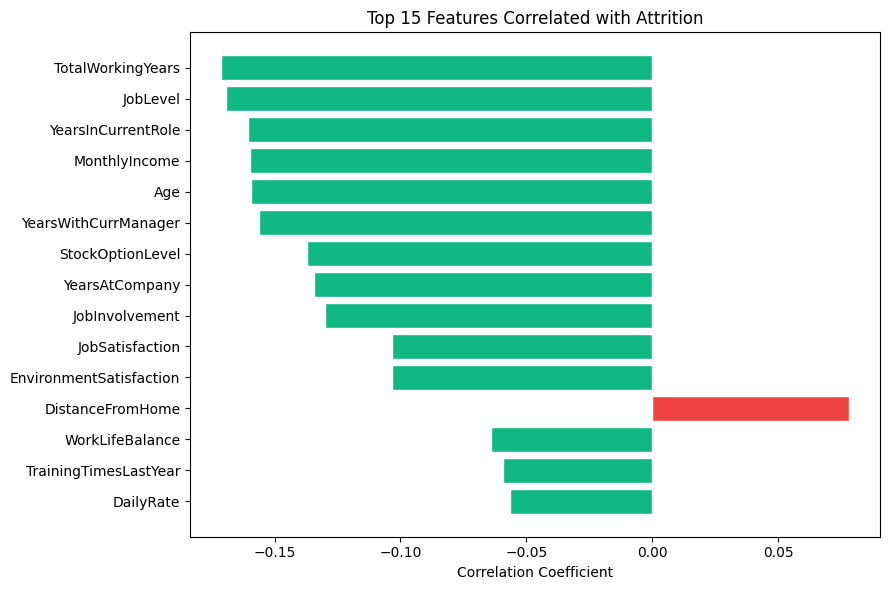

In [37]:
# Top correlations with attrition

attrition_corr = numeric_df.corr()["Attrition_num"].drop("Attrition_num")
attrition_corr = attrition_corr.sort_values(key=abs, ascending=False).head(15)
print("\nTop 15 Features Correlated with Attrition:")
print(attrition_corr.to_string())

plt.figure(figsize=(9, 6))
colors_corr = ["#ef4444" if v > 0 else "#10b981" for v in attrition_corr.values]
plt.barh(attrition_corr.index[::-1], attrition_corr.values[::-1],
         color=colors_corr[::-1], edgecolor="white")
plt.title("Top 15 Features Correlated with Attrition")
plt.xlabel("Correlation Coefficient")
plt.axvline(x=0, color="white", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig("trend_attrition_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
# FINAL SUMMARY NUMBERS FOR WEBSITE

print(f"\nTotal Employees       : {len(df)}")
print(f"Stayed                : {attrition_counts['No']} ({attrition_counts['No']/len(df)*100:.1f}%)")
print(f"Left                  : {attrition_counts['Yes']} ({attrition_counts['Yes']/len(df)*100:.1f}%)")
print(f"\nHighest Risk Role     : {role_rate.index[0]} ({role_rate.values[0]}%)")
print(f"Lowest Risk Role      : {role_rate.index[-1]} ({role_rate.values[-1]}%)")
print(f"\nOvertime Attrition    : {ot_rate.get('Yes', 'N/A')}%")
print(f"No Overtime Attrition : {ot_rate.get('No', 'N/A')}%")
print(f"\nHighest Risk Dept     : {dept_rate.index[0]} ({dept_rate.values[0]}%)")
print(f"\nSingle Attrition Rate : {marital_rate.get('Single', 'N/A')}%")
print(f"Married Attrition Rate: {marital_rate.get('Married', 'N/A')}%")
print(f"\nAge bracket 25-34     : highest attrition concentration")
print(f"\nStock Option 0 Rate   : {stock_rate.get(0, 'N/A')}%")
print(f"Stock Option 3 Rate   : {stock_rate.get(3, 'N/A')}%")


Total Employees       : 1470
Stayed                : 1233 (83.9%)
Left                  : 237 (16.1%)

Highest Risk Role     : Sales Representative (39.8%)
Lowest Risk Role      : Research Director (2.5%)

Overtime Attrition    : 30.5%
No Overtime Attrition : 10.4%

Highest Risk Dept     : Sales (20.6%)

Single Attrition Rate : 25.5%
Married Attrition Rate: 12.5%

Age bracket 25-34     : highest attrition concentration

Stock Option 0 Rate   : 24.4%
Stock Option 3 Rate   : 17.6%
